# 90-Day Segment Scenario Comparison

This notebook reuses the shared V2 model logic from hourly_shift_model_v2.py, which is also the importable source behind the V2 workflow.

It benchmarks every modeled scenario against an Actual Baseline (90d) reference built from the realized consumption in the shared 90-day evaluation period.

The only thing that changes across scenarios is the share of household load assigned to:
- ev
- 	hermal
- wet_loads

The residual share is kept as inflexible.

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

from hourly_shift_model_v2 import (
    FORECAST_HORIZON_HOURS,
    build_actual_baseline_reference,
    build_issue_catalog,
    build_segment_assumptions,
    load_predictions,
    load_system_load,
    run_scenario,
    summarize_actual_baseline,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

SIMULATION_DAYS = 90
NON_OVERLAPPING_WINDOW_DAYS = 5
SIMULATION_WINDOWS = SIMULATION_DAYS // NON_OVERLAPPING_WINDOW_DAYS

ACTUAL_BASELINE_LABEL = "Actual Baseline (90d)"
CURRENT_MIX_LABEL = "Current Mix (v2)"
MODELED_SCENARIO_ORDER = [
    CURRENT_MIX_LABEL,
    "Conservative",
    "2026 Normal",
    "2035 Simulation",
]
SCENARIO_ORDER = [
    ACTUAL_BASELINE_LABEL,
    *MODELED_SCENARIO_ORDER,
]
SCENARIO_COLORS = {
    ACTUAL_BASELINE_LABEL: "#455A64",
    CURRENT_MIX_LABEL: "#546E7A",
    "Conservative": "#1E88E5",
    "2026 Normal": "#43A047",
    "2035 Simulation": "#FB8C00",
}

SCENARIO_SHARES = {
    CURRENT_MIX_LABEL: {
        "wet_loads": 0.10,
        "thermal": 0.20,
        "ev": 0.10,
    },
    "Conservative": {
        "wet_loads": 0.075,
        "thermal": 0.09,
        "ev": 0.06,
    },
    "2026 Normal": {
        "wet_loads": 0.095,
        "thermal": 0.14,
        "ev": 0.10,
    },
    "2035 Simulation": {
        "wet_loads": 0.075,
        "thermal": 0.18,
        "ev": 0.22,
    },
}

In [16]:
# Shared scenario helpers are imported from hourly_shift_model_v2.py.

In [17]:
preds = load_predictions()
issue_catalog = build_issue_catalog(preds)
daily_issue_times = issue_catalog.loc[
    issue_catalog["issue_time"].dt.hour == 12,
    "issue_time",
].reset_index(drop=True)

system_load = load_system_load()

scenario_share_rows = []
for scenario_name in MODELED_SCENARIO_ORDER:
    assumptions = build_segment_assumptions(SCENARIO_SHARES[scenario_name])
    scenario_share_rows.append(
        {
            "scenario": scenario_name,
            "inflexible_share_pct": 100.0 * assumptions["inflexible"]["share_of_household_load"],
            "wet_loads_share_pct": 100.0 * assumptions["wet_loads"]["share_of_household_load"],
            "thermal_share_pct": 100.0 * assumptions["thermal"]["share_of_household_load"],
            "ev_share_pct": 100.0 * assumptions["ev"]["share_of_household_load"],
        }
    )

scenario_share_table = pd.DataFrame(scenario_share_rows).set_index("scenario")
display(scenario_share_table.round(1))

,inflexible_share_pct,wet_loads_share_pct,thermal_share_pct,ev_share_pct
scenario,,,,
Current Mix (v2),60.0,10.0,20.0,10.0
Conservative,77.5,7.5,9.0,6.0
2026 Normal,66.5,9.5,14.0,10.0
2035 Simulation,52.5,7.5,18.0,22.0


In [18]:
simulation_daily_issue_times = daily_issue_times.tail(SIMULATION_DAYS).reset_index(drop=True)
simulation_issue_times = simulation_daily_issue_times.iloc[::NON_OVERLAPPING_WINDOW_DAYS].reset_index(drop=True)

if len(simulation_issue_times) != SIMULATION_WINDOWS:
    raise ValueError(
        f"Expected {SIMULATION_WINDOWS} non-overlapping windows for {SIMULATION_DAYS} days, "
        f"but found {len(simulation_issue_times)}."
    )

simulation_window_summary = pd.Series(
    {
        "available_full_120h_issue_times": int(len(issue_catalog)),
        "available_daily_noon_issue_times": int(len(daily_issue_times)),
        "simulation_days": SIMULATION_DAYS,
        "non_overlapping_window_days": NON_OVERLAPPING_WINDOW_DAYS,
        "simulation_windows": int(len(simulation_issue_times)),
        "simulated_hours": int(len(simulation_issue_times) * FORECAST_HORIZON_HOURS),
        "first_issue_time": str(simulation_issue_times.iloc[0]),
        "last_issue_time": str(simulation_issue_times.iloc[-1]),
    }
)

display(simulation_window_summary.to_frame("value"))


,value
available_full_120h_issue_times,2162
available_daily_noon_issue_times,1081
simulation_days,90
non_overlapping_window_days,5
simulation_windows,18
simulated_hours,2160
first_issue_time,2025-10-03 12:00:00
last_issue_time,2025-12-27 12:00:00


In [19]:
actual_baseline_df = build_actual_baseline_reference(
    issue_times=simulation_issue_times,
    preds=preds,
    system_load=system_load,
)
actual_baseline_result = summarize_actual_baseline(actual_baseline_df, scenario_name=ACTUAL_BASELINE_LABEL)
actual_baseline_p95 = float(actual_baseline_result["baseline_system_load_p95_mwh"])

scenario_results = [actual_baseline_result] + [
    run_scenario(
        scenario_name=scenario_name,
        scenario_shares=SCENARIO_SHARES[scenario_name],
        issue_times=simulation_issue_times,
        preds=preds,
        system_load=system_load,
        baseline_reference_p95_mwh=actual_baseline_p95,
    )
    for scenario_name in MODELED_SCENARIO_ORDER
]

results_df = pd.DataFrame(scenario_results)
results_df = (
    results_df.set_index("scenario")
    .loc[SCENARIO_ORDER]
    .reset_index()
)

actual_baseline_shifted_energy = float(
    results_df.loc[
        results_df["scenario"] == ACTUAL_BASELINE_LABEL,
        "total_shifted_energy_mwh",
    ].iloc[0]
)
actual_baseline_p95 = float(
    results_df.loc[
        results_df["scenario"] == ACTUAL_BASELINE_LABEL,
        "shifted_system_load_p95_mwh",
    ].iloc[0]
)
actual_baseline_hours_above_p95 = int(
    results_df.loc[
        results_df["scenario"] == ACTUAL_BASELINE_LABEL,
        "shifted_hours_above_p95",
    ].iloc[0]
)

results_df["delta_vs_actual_baseline_shifted_energy_mwh"] = (
    results_df["total_shifted_energy_mwh"] - actual_baseline_shifted_energy
)
results_df["delta_vs_actual_baseline_p95_mwh"] = (
    results_df["shifted_system_load_p95_mwh"] - actual_baseline_p95
)
results_df["delta_vs_actual_baseline_hours_above_p95"] = (
    results_df["shifted_hours_above_p95"] - actual_baseline_hours_above_p95
)

display(
    results_df[
        [
            "scenario",
            "simulation_days",
            "shift_events",
            "total_shifted_energy_mwh",
            "shifted_share_of_system_consumption_pct",
            "shifted_share_of_household_consumption_pct",
            "baseline_system_load_p95_mwh",
            "shifted_system_load_p95_mwh",
            "delta_vs_actual_baseline_p95_mwh",
            "realized_household_savings_eur",
        ]
    ].round(2)
)



,scenario,simulation_days,shift_events,total_shifted_energy_mwh,shifted_share_of_system_consumption_pct,shifted_share_of_household_consumption_pct,baseline_system_load_p95_mwh,shifted_system_load_p95_mwh,delta_vs_actual_baseline_p95_mwh,realized_household_savings_eur
0,Actual Baseline (90d),90.0,0,0.00,0.00,0.00,3367.89,3367.89,0.00,0.00
1,Current Mix (v2),90.0,5453,63350.76,1.04,3.14,3367.89,3355.35,-12.54,1483321.32
2,Conservative,90.0,5453,37003.54,0.60,1.83,3367.89,3357.86,-10.03,871685.91
3,2026 Normal,90.0,5453,55023.44,0.90,2.72,3367.89,3357.66,-10.23,1294310.55
4,2035 Simulation,90.0,5453,81039.08,1.32,4.01,3367.89,3356.50,-11.38,1907242.24


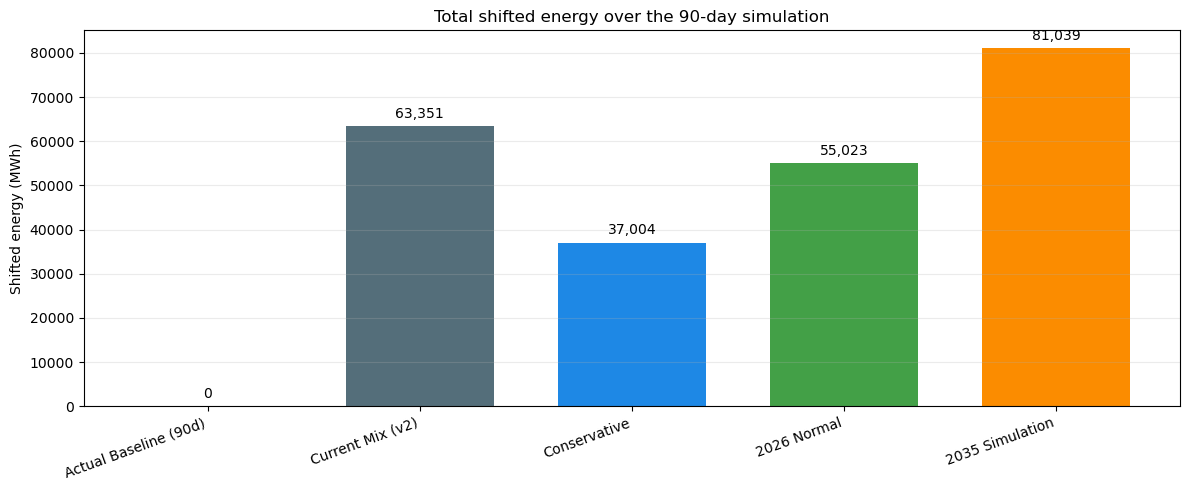

In [20]:
plot_df = results_df.copy()
bar_colors = [SCENARIO_COLORS[scenario] for scenario in plot_df["scenario"]]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    plot_df["scenario"],
    plot_df["total_shifted_energy_mwh"],
    color=bar_colors,
    width=0.7,
)

ax.set_title("Total shifted energy over the 90-day simulation")
ax.set_ylabel("Shifted energy (MWh)")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.25)

ymax = float(plot_df["total_shifted_energy_mwh"].max())
for bar, value in zip(bars, plot_df["total_shifted_energy_mwh"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + ymax * 0.015,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.xticks(rotation=20, ha="right")
plt.tight_layout()


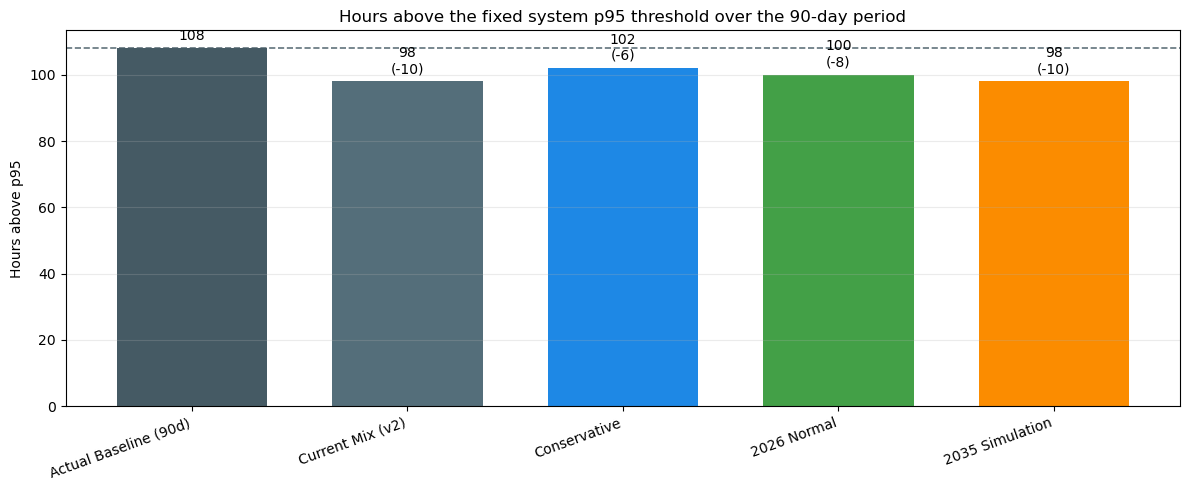

In [21]:
plot_df = results_df.copy()
bar_colors = [SCENARIO_COLORS[scenario] for scenario in plot_df["scenario"]]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    plot_df["scenario"],
    plot_df["shifted_hours_above_p95"],
    color=bar_colors,
    width=0.7,
)

ax.axhline(
    actual_baseline_hours_above_p95,
    color=SCENARIO_COLORS[ACTUAL_BASELINE_LABEL],
    linestyle="--",
    linewidth=1.2,
    alpha=0.85,
)

ax.set_title("Hours above the fixed system p95 threshold over the 90-day period")
ax.set_ylabel("Hours above p95")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.25)

ymax = float(plot_df["shifted_hours_above_p95"].max())
for bar, scenario_name, value, delta in zip(
    bars,
    plot_df["scenario"],
    plot_df["shifted_hours_above_p95"],
    plot_df["delta_vs_actual_baseline_hours_above_p95"],
):
    label = f"{int(value):,}" if scenario_name == ACTUAL_BASELINE_LABEL else f"{int(value):,}\n({int(delta):+d})"
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(ymax * 0.015, 1.0),
        label,
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
